In [1]:
import sys
import importlib
import os
sys.path.append(os.path.abspath(".."))

import pipeline.io as io
import pipeline.data_handler as dh
import matplotlib.pyplot as plt



In [2]:
"""Plotting code to visual the dataframes as they go through the pipeline"""
def plot_lightcurve(df):
    plt.figure(figsize=(8, 5))

    plt.plot(df[0], df[1], '.', markersize=4)

    plt.xlabel("Time")
    plt.ylabel("Magnitude")
    plt.title("Lightcurve")
    plt.gca().invert_yaxis()  # important for astronomy magnitudes

    plt.tight_layout()
    plt.show()

In [3]:
print(dir(io))

['Path', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'create_file_list', 'csv_handler', 'json_handler', 'lightcurve_reader', 'multi_lightcurve_reader', 'pd', 'tab_handler', 'txt_handler', 'xml_handler']


In [4]:
valid_tab_path = '/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999/13651_19970305.tab'
valid_xml_path = '/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999/13651_19970203.xml'

In [5]:
data_valid_tab, metadata, code_valid_tab = io.lightcurve_reader(valid_tab_path)
print(data_valid_tab, code_valid_tab)

[             0       1
0  50512.79195  19.015
1  50512.86314  19.057
2  50512.91949  19.031] 0


In [6]:
data_valid_xml, metadata,code_valid_xml = io.lightcurve_reader(valid_xml_path)
print(data_valid_xml, code_valid_xml)

Reading of file: /Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999/13651_19970203.xml failed.
None -1


In [7]:
print(io.create_file_list('/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999', 'tab', id_string='13651'))



files = io.create_file_list('/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999', 'tab', id_string='35107')
print(files[0])
files_0 = [files[2]]
print(files)

data, metadata, exit_status = io.multi_lightcurve_reader(files)
print(data)
print(len(files))
print(len(data))
print(metadata)

[PosixPath('/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999/13651_19970209.tab'), PosixPath('/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999/13651_19970224.tab'), PosixPath('/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999/13651_19970226.tab'), PosixPath('/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999/13651_19970131.tab'), PosixPath('/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999/13651_19970301.tab'), PosixPath('/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999/13651_19970303.tab'), PosixPath('/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999/13651_19970302.tab'), PosixPath('/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999/13651_19970307.tab'), PosixPath('/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999/13651_19970305.tab'), 

In [22]:
importlib.reload(dh)


<module 'pipeline.data_handler' from '/Users/smores/Desktop/school/S26/computationalastro/Asteroid-Period-Finder/pipeline/data_handler.py'>

In [12]:
data, metadata, exit_status = io.lightcurve_reader('/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999/35107_19970310.tab')

In [31]:
data, metadata, exit_status = io.lightcurve_reader('/Users/smores/Desktop/school/S26/computationalastro/Asteroid-Period-Finder/data/ALCDEF/ALCDEF_65_Cybele_20260506_001647.txt')

In [32]:
print(metadata)

[{'REVISEDDATA': 'FALSE', 'ALLOWSHARING': 'TRUE', 'SUBMITPDS': 'TRUE', 'LASTUPDATE': '2018-12-07 00:00:00', 'LCBLOCKID': '707', 'OBJECTNUMBER': '65', 'OBJECTNAME': 'Cybele', 'MPCDESIG': '', 'SESSIONDATE': '2009-07-31', 'SESSIONTIME': '09:24:49', 'CONTACTNAME': 'F. Pilcher', 'CONTACTINFO': '[pilcher@ic.edu]', 'OBSERVERS': 'F. Pilcher', 'FACILITY': 'Organ Mesa Observatory', 'MPCCODE': 'G50', 'TELESCOPE': '0.35-m SCT', 'DETECTOR': 'SBIG STL-1001E', 'OBSLONGITUDE': '-106.670000', 'OBSLATITUDE': '+32.296111', 'EXPOSURE': '-99', 'EXPJD': 'MID', 'OBJECTRA': '23:26.5', 'OBJECTDEC': '-03 54', 'EQUINOX': 'J2000.0', 'PHASE': '+11.91', 'PABL': '+344.8', 'PABB': '-0.2', 'FILTER': 'R', 'MAGBAND': 'R', 'CICORRECTION': 'FALSE', 'CIBAND': 'NONE', 'CITARGET': '-99.9', 'DIFFERMAGS': 'TRUE', 'DIFFZEROMAG': '-99.9', 'STANDARD': 'NONE', 'LTCAPP': 'NONE', 'REDUCEDMAGS': 'NONE', 'PUBLICATION': 'BIBCODE=COMMENT=The original SessionDate/Time were adjusted to match the average JD of the lightcurve data', 'DELIMI

In [33]:
processed = dh.process_lightcurve(data, metadata)

In [34]:
dh.check_relative_mags(metadata)

True

In [35]:
import pipeline.fourier_engine as fe
import numpy as np

importlib.reload(fe)

frequencies, powers, fpeak = fe.lomb_scargle(processed['jd_corrected'], processed[1])

print(fpeak)

7.889479452054822


In [36]:
print(processed)
print((processed['jd_corrected'] - processed[0]).describe())

                 0         1  uncertainty  jd_corrected
0     2.455044e+06  0.007842        0.004  2.455044e+06
1     2.455044e+06  0.011854        0.004  2.455044e+06
2     2.455044e+06 -0.001133        0.004  2.455044e+06
3     2.455044e+06  0.010888        0.004  2.455044e+06
4     2.455044e+06  0.012900        0.004  2.455044e+06
...            ...       ...          ...           ...
3687  2.455930e+06 -0.021821        0.004  2.455930e+06
3688  2.455930e+06 -0.024852        0.004  2.455930e+06
3689  2.455930e+06 -0.020872        0.004  2.455930e+06
3690  2.455930e+06 -0.020883        0.004  2.455930e+06
3691  2.455930e+06 -0.030934        0.004  2.455930e+06

[3692 rows x 4 columns]
count    3692.000000
mean       -0.015511
std         0.001526
min        -0.017668
25%        -0.017055
50%        -0.016114
75%        -0.013763
max        -0.013626
dtype: float64


                0      1  uncertainty
0    2.455044e+06  0.083        0.004
1    2.455044e+06  0.087        0.004
2    2.455044e+06  0.074        0.004
3    2.455044e+06  0.086        0.004
4    2.455044e+06  0.088        0.004
..            ...    ...          ...
161  2.455044e+06  0.060        0.006
162  2.455044e+06  0.060        0.005
163  2.455044e+06  0.056        0.006
164  2.455044e+06  0.058        0.006
165  2.455044e+06  0.064        0.009

[166 rows x 3 columns]
{'REVISEDDATA': 'FALSE', 'ALLOWSHARING': 'TRUE', 'SUBMITPDS': 'TRUE', 'LASTUPDATE': '2018-12-07 00:00:00', 'LCBLOCKID': '707', 'OBJECTNUMBER': '65', 'OBJECTNAME': 'Cybele', 'MPCDESIG': '', 'SESSIONDATE': '2009-07-31', 'SESSIONTIME': '09:24:49', 'CONTACTNAME': 'F. Pilcher', 'CONTACTINFO': '[pilcher@ic.edu]', 'OBSERVERS': 'F. Pilcher', 'FACILITY': 'Organ Mesa Observatory', 'MPCCODE': 'G50', 'TELESCOPE': '0.35-m SCT', 'DETECTOR': 'SBIG STL-1001E', 'OBSLONGITUDE': '-106.670000', 'OBSLATITUDE': '+32.296111', 'EXPOSURE':

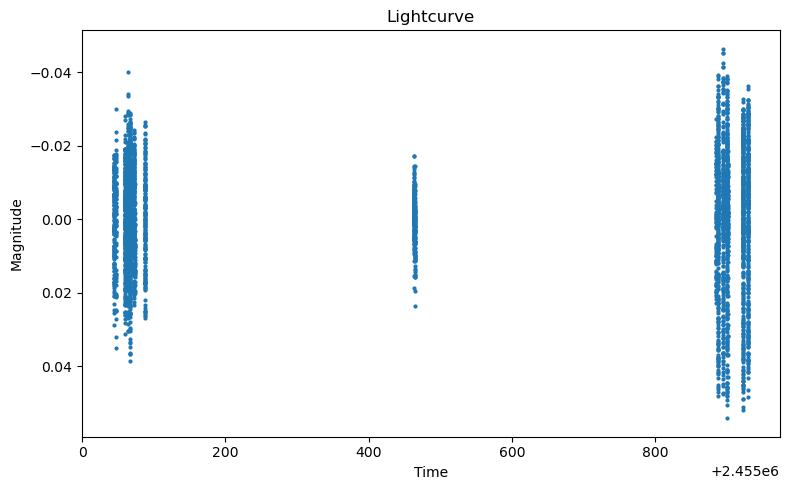

In [37]:
print(data[0])
print(metadata[0])

print(metadata[0]['LTCAPP'])


plot_lightcurve(processed)

Top 10 peaks:
Rank   Frequency (c/d)      Period (hr)     Power     
-------------------------------------------------------
1      7.8895               3.042           342.6169  
2      8.8966               2.698           335.3209  
3      7.8919               3.041           330.8172  
4      3.9470               6.081           329.3963  
5      11.8396              2.027           328.3608  
6      11.8407              2.027           318.9506  
7      8.8941               2.698           314.7518  
8      11.8385              2.027           311.1070  
9      7.8930               3.041           309.8933  
10     7.8941               3.040           309.6515  

Known double frequency: 1.4502 c/d (P = 16.55 hr)


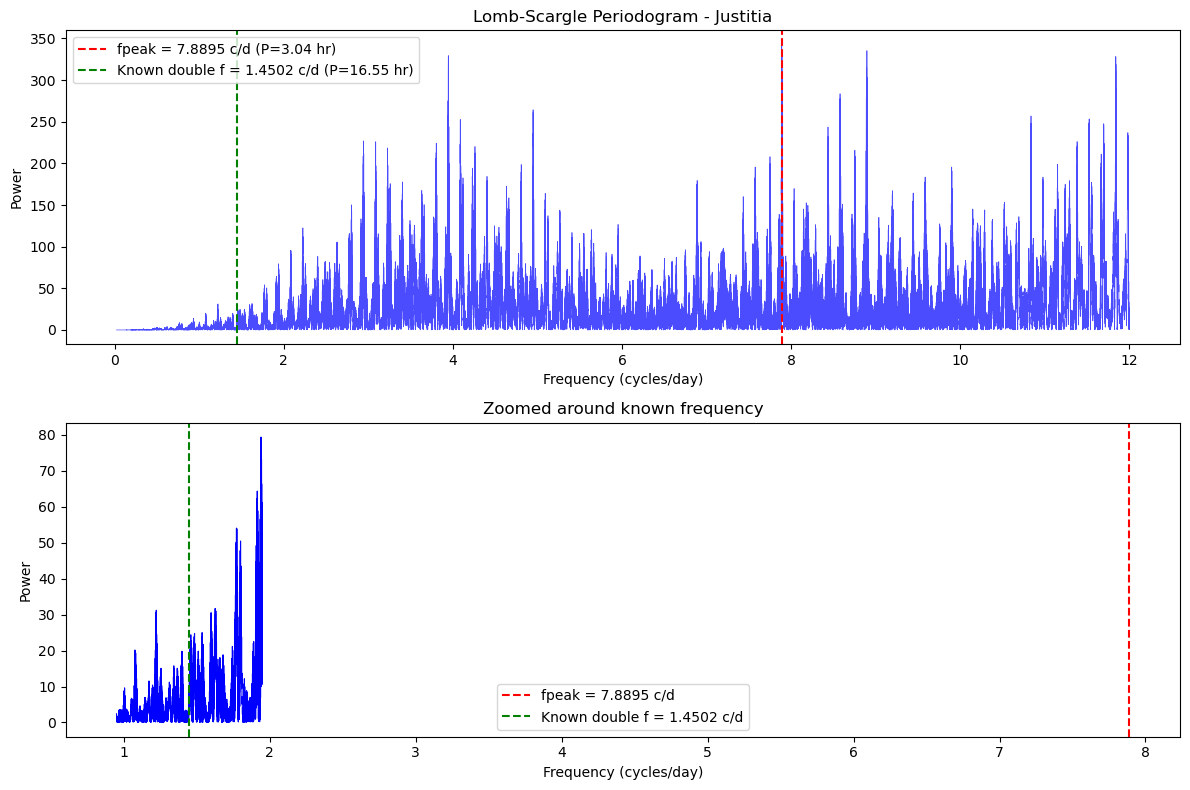

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Top 10 peaks
top10_idx = np.argsort(powers)[-10:][::-1]
print("Top 10 peaks:")
print(f"{'Rank':<6} {'Frequency (c/d)':<20} {'Period (hr)':<15} {'Power':<10}")
print("-" * 55)
for rank, idx in enumerate(top10_idx):
    f = frequencies[idx]
    p = 24 / f
    print(f"{rank+1:<6} {f:<20.4f} {p:<15.3f} {powers[idx]:<10.4f}")

# mark known frequency
f_known_double = 2 * (24/33.1)
print(f"\nKnown double frequency: {f_known_double:.4f} c/d (P = {24/f_known_double:.2f} hr)")

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Full periodogram
ax1.plot(frequencies, powers, 'b-', linewidth=0.5, alpha=0.7)
ax1.axvline(fpeak, color='red', linestyle='--', label=f'fpeak = {fpeak:.4f} c/d (P={24/fpeak:.2f} hr)')
ax1.axvline(f_known_double, color='green', linestyle='--', label=f'Known double f = {f_known_double:.4f} c/d (P={24/f_known_double:.2f} hr)')
ax1.set_xlabel('Frequency (cycles/day)')
ax1.set_ylabel('Power')
ax1.set_title('Lomb-Scargle Periodogram - Justitia')
ax1.legend()

# Zoomed in around the true frequency
f_center = f_known_double
f_window = 0.5
mask = (frequencies >= f_center - f_window) & (frequencies <= f_center + f_window)
ax2.plot(frequencies[mask], powers[mask], 'b-', linewidth=0.8)
ax2.axvline(fpeak, color='red', linestyle='--', label=f'fpeak = {fpeak:.4f} c/d')
ax2.axvline(f_known_double, color='green', linestyle='--', label=f'Known double f = {f_known_double:.4f} c/d')
ax2.set_xlabel('Frequency (cycles/day)')
ax2.set_ylabel('Power')
ax2.set_title('Zoomed around known frequency')
ax2.legend()

plt.tight_layout()
plt.show()

In [39]:
import pipeline.harmonic_logic as hl
importlib.reload(hl)


best_frot, period_hours, best_coeffs, is_double_peaked = hl.harmonic_logic(
    processed['jd_corrected'].values, 
    processed[1].values, 
    frequencies, 
    powers
)


Found 4 clusters, refining each...
  Cluster f=7.8895 c/d → frot=3.9459 c/d (P=6.082 hr), chi2=0.000186, double=True
  Cluster f=8.8966 c/d → frot=4.0907 c/d (P=5.867 hr), chi2=0.000222, double=True
  Cluster f=3.9470 c/d → frot=3.9482 c/d (P=6.079 hr), chi2=0.000200, double=False
  Cluster f=11.8396 c/d → frot=11.8408 c/d (P=2.027 hr), chi2=0.000216, double=False

Best rotation frequency: 3.945924 c/d
Best period: 6.0822 hours
Chi2 single harmonic: 0.000228
Chi2 double harmonic: 0.000186
Double peaked: True


Figure saved to ../outputs/269 Justitia_results.png


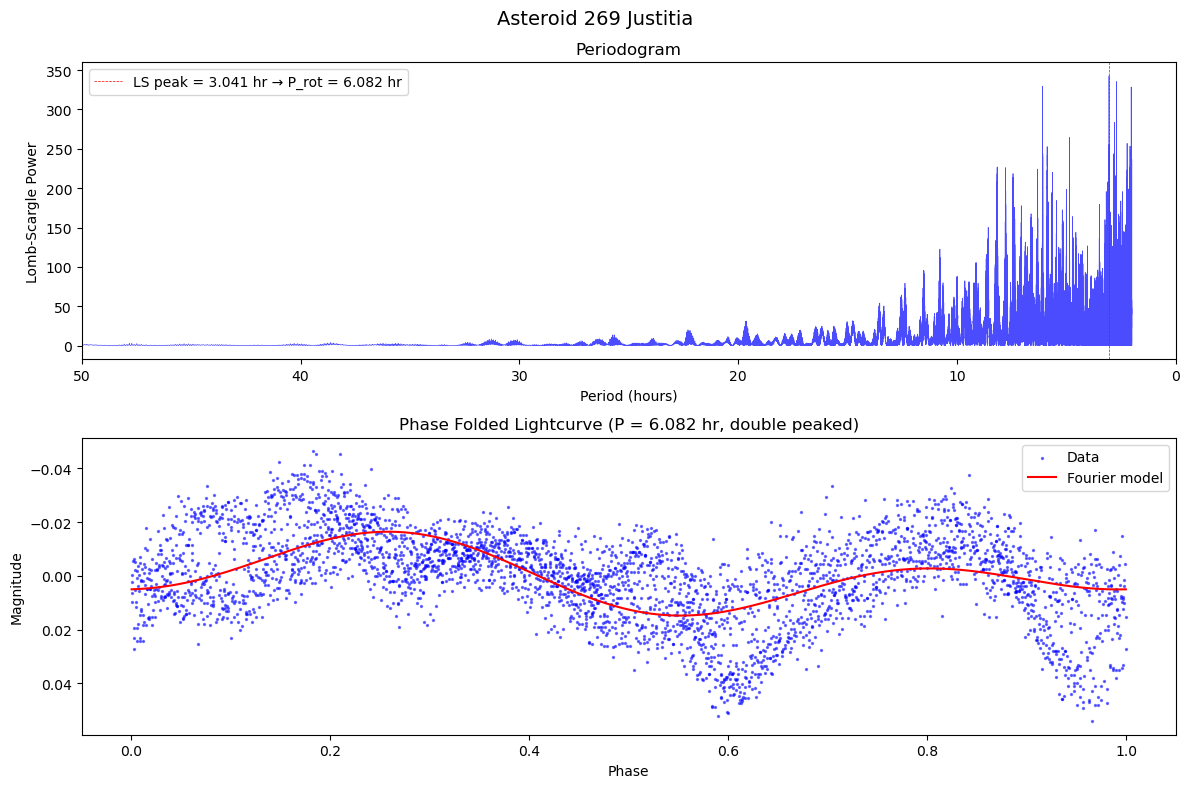

JSON summary saved to ../outputs/269 Justitia_results.json


In [40]:
import pipeline.output_gen as og
importlib.reload(og)

fig, summary = og.generate_output(
    t=processed['jd_corrected'].values,
    y=processed[1].values,
    frequencies=frequencies,
    powers=powers,
    period_hours=period_hours,
    best_frot=best_frot,
    best_coeffs=best_coeffs,
    is_double_peaked=is_double_peaked,
    asteroid_name='269 Justitia',
    output_dir='../outputs'
)

In [41]:
frot, coeffs, chi2 = hl.refine_period(processed['jd_corrected'].values, processed[1].values, 1.5630)

Figure saved to ../outputs/269 Justitia_results.png


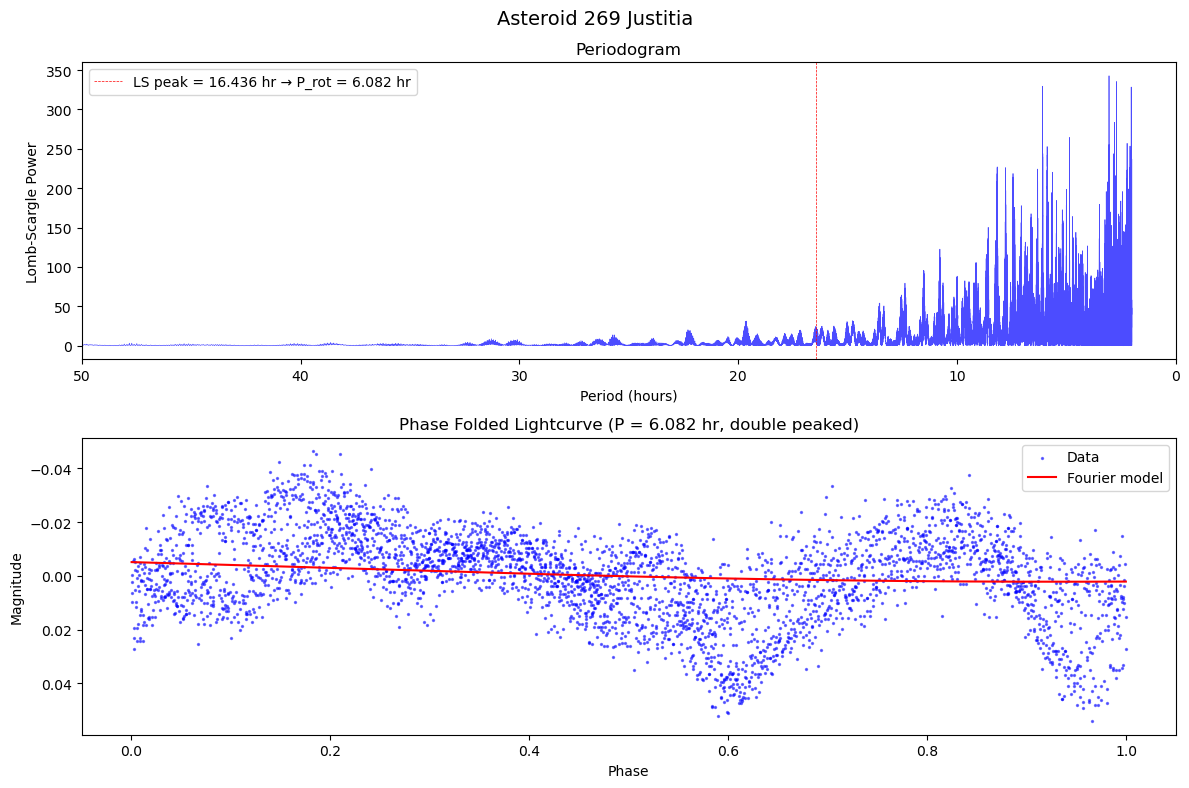

JSON summary saved to ../outputs/269 Justitia_results.json


In [42]:
fig, summary = og.generate_output(
    t=processed['jd_corrected'].values,
    y=processed[1].values,
    frequencies=frequencies,
    powers=powers,
    period_hours=period_hours,
    best_frot=frot,
    best_coeffs=coeffs,
    is_double_peaked=is_double_peaked,
    asteroid_name='269 Justitia',
    output_dir='../outputs'
)